***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [第 2 章：干涉测量的数学工具箱](2_0_introduction.ipynb)
    * 上一节：[2.9 采样理论：离散测量的分辨率与混叠](2_9_sampling_theory.ipynb)
    * 下一节：[2.11 最小二乘与参数估计](2_11_least_squares.ipynb)

***


导入标准模块：

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from IPython.display import HTML
except ImportError:
    def HTML(*args, **kwargs):
        return None
%matplotlib inline
HTML('../style/course.css')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


## 2.10 线性代数：从测量方程到矩阵表示<a id='math:sec:lin_alg'></a>


从第 4 章开始，可见度方程、成像方程和校准方程都会越来越频繁地写成向量与矩阵形式。那时如果我们只停留在“会认符号”的层面，很多公式就会显得突兀而抽象。

因此，本节并不追求线性代数的百科式回顾，而是聚焦干涉测量里最常见的矩阵语言：向量空间、内积、矩阵乘法、线性系统，以及卷积矩阵和正规方程的基本结构。它的作用，是把前面建立的函数语言进一步转化为可计算、可求解的方程语言。


### 2.10.1 向量<a id='math:sec:lin_alg_vectors'></a>

在后续章节里，一个由多条基线组成的可见度集合可以写成向量，待求解的天线增益也可以写成向量，图像像素值同样可以堆叠成向量。把许多耦合标量方程收集成一个向量，并不是记号游戏，而是为了让问题结构一眼可见：哪些量是未知量，哪些量是观测量，哪些量是算子作用后的结果。


**定义**：一个 $n$ 维列向量 ${\bf v } \in\mathbb{C}^{n\times 1}$，是由 $n$ 个复数组成的有序集合，即 $v_1,v_2,....v_n$，按如下方式堆叠：

\begin{equation}
{\bf v } = \begin{pmatrix}
v_1\\
v_2\\
\vdots\\
v_n
\end{pmatrix}.
\end{equation}

一个 $n$ 维行向量 ${\bf u}^T \in\mathbb{C}^{1\times n}$，也是由 $n$ 个复数组成的有序集合，即 $u_1,u_2,....u_n$，写作

\begin{equation}
{\bf u }^T=(u_1,u_2,....u_n).
\end{equation}

注意，在这里的记号约定中，向量 $\bf{v}$ 默认总是列向量；若要表示行向量，我们会显式写出上标 $T$，表明它是某个向量的转置。因此，记号 ${\bf{v}}\in\mathbb{C}^{n}$ 应理解为列向量。

这个“默认列向量”的约定在后续非常重要，因为它决定了算子总是从左侧作用：测量矩阵乘在未知向量左边，权重矩阵乘在残差向量左边，正规方程也都写成统一的矩阵乘法形式。这样做的好处，是一旦把问题离散化，我们几乎总能把它看成“某个线性映射作用在一个列向量上”。

#### 2.10.1.1 向量乘积

设 ${\bf{u}},{\bf{v}}\in \mathbb{C}^{n}$。下面这些向量乘积在射电干涉测量中经常出现：

1. **厄米内积**

   ${\bf{u}}$ 与 ${\bf{v}}$ 的 厄米内积定义为

   \begin{equation}
   {\bf{u}}\cdot{\bf{v}} = {\bf u}^H {\bf v} = \sum_{i=1}^n u_i^*v_i,
   \end{equation}

   其中上标 $H$ 表示 厄米转置（见下文）。回忆一下，当实向量 ${\bf b} \in \mathbb{R}^n$ 与实单位向量 $\hat{{\bf a}} \in \mathbb{R}^n$ 做内积时，结果给出的是 ${\bf b}$ 在 $\hat{{\bf a}}$ 所定义方向上的分量。这里 $\hat{{\bf a}} = {\bf \frac{a}{|a|}}$。实向量上的内积有时也称为点积（dot product），我们说它把 ${\bf b}$ 投影到了 $\hat{{\bf a}}$ 上。显式地，

   \begin{equation}
   {\bf b }\cdot{\bf \hat{a}} = |{\bf b}| \ |{\bf \hat{a}}| \cos(\kappa) = |{\bf b}|\cos(\theta),
   \end{equation}

   其中 $|\cdot|$ 表示向量的模，$\kappa$ 是 $\hat{{\bf a}}$ 与 ${\bf b }$ 之间的锐角。这一几何意义如 [图 2.10.1 &#10549;](#pos:fig:projection) <!--\ref{pos:fig:projection}--> 所示。<br><br>

2. **外积**

   ${\bf{u}}$ 与 ${\bf{v}}$ 的外积定义为

   \begin{equation}
   {\bf u} * {\bf v} = {\bf u }{\bf v}^H, \quad \rightarrow \quad {({\bf{u}}*{\bf{v}})}_{ij} = u_iv_j^*
   \end{equation}

   外积也可以赋予几何解释。若两个向量都是单位向量，即 ${\bf \hat{u}}$ 与 ${\bf \hat{v}}$，那么可以把外积看成一个作用在任意向量 ${\bf x}$ 上的算子，其结果为

   \begin{equation}
   ({\bf \hat{u}} * {\bf \hat{v}}) {\bf x}  = {\bf \hat{u} }{\bf \hat{v}}^H {\bf x} = {\bf \hat{u} }({\bf \hat{v}}\cdot {\bf x}).
   \end{equation}

   也就是说，这个算子先取出 ${\bf x}$ 在 ${\bf \hat{v}}$ 方向上的分量，再把该分量指向 ${\bf \hat{u}}$ 的方向。<br><br>

在干涉测量语境下，这几种乘积各自对应不同的物理对象。内积常用来表达相关、加权残差或能量；外积则经常生成秩 1 矩阵，例如由单个向量构造协方差、相干矩阵或方向响应。只要理解了“内积是在做投影，外积是在构造线性算子”，后面很多紧凑写法就不会显得神秘。 

<img src='figures/projection.png' width=40%>

<div align="center">**图 2.10.1**：用点积把 ${\bf b}$ 投影到 ${\bf \hat{a}}$ 上。</div> <a id='pos:fig:projection'></a> <!--\label{pos:fig:projection}-->

### 2.10.2 矩阵 <a id='math:sec:lin_alg_matrices'></a>

矩阵在本书中通常扮演三类角色：第一，它表示一个线性映射，例如采样、傅里叶变换或加权；第二，它压缩了多天线系统中的耦合关系，例如极化响应或增益链；第三，它是构造正规方程、协方差和近似海森矩阵的自然容器。读者在阅读下面的定义时，不妨始终带着一个问题：这个矩阵究竟作用在什么对象上？


**定义**：矩阵 ${\bf{A}}\in \mathbb{C}^{m\times n}$ 定义为一个由复数组成的有序矩形数组，即
\begin{equation}
{\bf{A}} = \begin{pmatrix} a_{11}&a_{12}&\dots& a_{1n}\\
a_{21}&a_{22}&\dots &a_{2n}\\
\vdots&\vdots&\ddots &\vdots\\
a_{m1}&a_{m2}&\dots &a_{mn}
\end{pmatrix}
\end{equation}

如果 $m=n$，那么 ${\bf{A}}$ 就是方阵。注意，第一个下标表示行号，第二个下标表示列号。

#### 2.10.2.1 基本矩阵操作与性质

1. ${\bf{A}}\in \mathbb{C}^{m\times n}$ 的转置记作 ${\bf{A}}^T$，定义为
   \begin{equation}
   {\bf{A}}^T_{ij} = a_{ji},
   \end{equation}
   即转置运算交换矩阵的行与列。

2. ${\bf{A}}\in \mathbb{C}^{m\times n}$ 的复共轭记作 ${\bf{A}}^*$，定义为
   \begin{equation}
   {\bf{A}}^*_{ij} = a_{ij}^*.
   \end{equation}

3. ${\bf{A}}\in \mathbb{C}^{m\times n}$ 的 厄米转置记作 ${\bf{A}}^H$，定义为
   \begin{equation}
   {\bf{A}}^H_{ij} = a_{ji}^*,
   \end{equation}
   也就是说，厄米转置等于“先转置再取共轭”，即 ${\bf A}^H = ({\bf A}^T)^*$。

4. 矩阵 ${\bf{A}}\in \mathbb{C}^{m\times n}$ 的向量化记作 vec$({\bf{A}})$，它是一个 $mn \times 1$ 的列向量，由把矩阵 ${\bf{A}}$ 的各列依次上下堆叠得到：
   \begin{equation}
    \mathrm{vec}({\bf{A}}) = [a_{11}, \ldots, a_{m1}, a_{12}, \ldots, a_{m2}, \ldots,
    a_{1n},\ldots, a_{mn}]^T
   \end{equation}
   vec$({\bf{A}})$ 的逆运算记作 vec$^{-1}({\bf{A}})$。这里我们把它称作矩阵化（matrization）。不要把它与 matricization 混淆；后者是向量化在高阶张量上的推广。

5. 我们用 diag$({\bf u})$ 表示一个对角线等于 ${\bf u}$、其余元素全为零的矩阵。反过来，当 diag 应用于矩阵 ${\bf A}$ 时，diag$({\bf A})$ 表示由 ${\bf A}$ 的对角元素提取出来的向量。

6. 一个方阵 ${\bf{A}}\in \mathbb{C}^{m\times m}$ 可以具有以下性质：

     * **可逆**：若存在矩阵 ${\bf{B}}\in \mathbb{C}^{m\times m}$ 使得
       \begin{equation}
       {\bf{B}}{\bf{A}} = {\bf{A}}{\bf{B}} = {\bf{I}}.
       \end{equation}
       此时记 ${\bf{A}}$ 的逆为 ${\bf{A}}^{-1}$。
     * **厄米**：若 ${\bf{A}} = {\bf{A}}^H$。
     * **（特殊）正交**：若 ${\bf A}{\bf A}^T = I \rightarrow {\bf{A}}^{-1} = {\bf{A}}^T$。
     * **（特殊）酉**：若 ${\bf A}{\bf A}^H = I \rightarrow {\bf{A}}^{-1} = {\bf{A}}^H$。

7. 我们用 $|{\bf{A}}|$ 表示方阵 ${\bf{A}}$ 的行列式（可参见 [Wikipedia &#10142;](https://en.wikipedia.org/wiki/Determinant)）。

这些操作之所以会在后文反复出现，并不是因为线性代数教科书都会列它们，而是因为干涉测量的核心公式几乎都离不开它们：厄米转置出现在加权内积与正规方程里，diag 用来构造权重与增益矩阵，vec 用来把矩阵方程改写成线性系统，而“可逆/厄米/酉”这些性质则直接决定了一个问题是否稳定、是否便于求解。 

#### 2.10.2.2 矩阵乘积

射电干涉测量中常会遇到几种特定的矩阵乘积。下面给出本课程中最常使用的定义（另见 [<cite data-cite='Liu2008'>Hadamard, Khatri-Rao, Kronecker and other matrix products</cite> &#10548;](https://www.researchgate.net/profile/Shuangzhe_Liu/publication/251677036_HADAMARD_KHATRI-RAO_KRONECKER_AND_OTHER_MATRIX_PRODUCTS/links/02e7e5375f06540414000000.pdf)，但请注意本文的记号与该文不同）。

下文假设 ${\bf{A}},{\bf{C}}\in\mathbb{C}^{m\times n}$，${\bf{B}}\in\mathbb{C}^{p\times q}$，${\bf{D}}\in\mathbb{C}^{n\times r}$。有时我们还需要把矩阵分块成若干子矩阵。这里用粗体下标表示子矩阵。例如，记号 ${\bf{A}}_{\bf ij}$ 表示矩阵 ${\bf A}$ 的一个子矩阵 ${\bf{A}}_{\bf ij}\in\mathbb{C}^{m_i\times n_j}$。因此，粗体下标 ${\bf i}$ 与 ${\bf j}$ 本身分别是长度为 $m_i$ 与 $n_j$ 的索引列表。类似地，${\bf{B}}_{\bf kl}$ 表示矩阵 ${\bf B}$ 的子矩阵 ${\bf{B}}_{\bf kl}\in\mathbb{C}^{p_k\times q_l}$，其中粗体下标 ${\bf k}$ 与 ${\bf l}$ 分别是长度为 $p_k$ 与 $q_l$ 的索引列表。这个记号的含义在下面的例子中会更清楚。现在先记住：这些粗体下标是索引列表，而且它们的元素不必从 1 开始连续编号（见下文 Kronecker 积的定义）。另外，满足 $\sum m_i = m$、$\sum n_j = n$、$\sum p_k = p$、$\sum q_l = q$。基于这些约定，我们定义如下矩阵乘积：

1. **矩阵乘积**

   ${\bf{A}}$ 与 ${\bf{D}}$ 的矩阵乘积记作 ${\bf{A}}{\bf{D}}$，其尺寸为 $m\times r$。矩阵乘积的第 $ij$ 个元素为

   \begin{equation}
   ({\bf{A}} {\bf{D}})_{ij} = \sum^n_{k=1} a_{ik}d_{kj}.
   \end{equation}

   注意，只有当 ${\bf{A}}$ 的列数等于 ${\bf{D}}$ 的行数时，这个乘积才有定义。<br><br>

2. **Hadamard 积**

   ${\bf{A}}$ 与 ${\bf{C}}$ 的 Hadamard 积记作 ${\bf{A}}\odot{\bf{C}}$，它是逐元素乘积，即

   \begin{equation}
   {({\bf{A}} \odot {\bf{C}})}_{ij} = a_{ij}c_{ij}.
   \end{equation}

   注意，只有当 ${\bf{A}}$ 与 ${\bf{C}}$ 的尺寸相同，这个乘积才有定义；结果矩阵的尺寸也与两者相同。我们还可以定义矩阵 ${\bf A}$ 的 Hadamard 逆（即逐元素求逆），其第 $ij$ 个元素为
   \begin{equation}
   (A^{\odot -1})_{ij} = \frac{1}{a_{ij}}
   \end{equation} <br>

3. **Kronecker 积**

   ${\bf A}$ 与 ${\bf B}$ 的 Kronecker 积记作 ${\bf A} \otimes {\bf B}$。它把 ${\bf A}$ 的每个元素都与整个 ${\bf B}$ 相乘，并把结果按下列形式排成一个大矩阵：

   \begin{equation}
   {\bf{A}} \otimes {\bf{B}} = \left(\begin{array}{ccc}a_{11}{\bf B} & a_{12}{\bf B} & \cdots & a_{1n}{\bf B} \\ a_{21}{\bf B} & a_{22}{\bf B} & \cdots & a_{2n}{\bf B} \\ \cdot & \cdot & \cdot & \cdot \\ a_{m1}{\bf B} & a_{m2}{\bf B} & \cdots & a_{mn}{\bf B} \end{array}\right).
   \end{equation}

   因此结果矩阵的尺寸为 $mp\times nq$。利用前面引入的粗体下标，也可以写成

   \begin{equation}
   ({\bf{A}} \otimes {\bf{B}})_{\bf ij} = a_{ij}{\bf{B}}.
   \end{equation}

   注意，粗体下标 ${\bf ij}$ 总是对应原矩阵 ${\bf A}$ 中元素 $a_{ij}$ 所在的位置。若把 Kronecker 积的结果记为 ${\bf Q} = {\bf{A}} \otimes {\bf{B}}$，其中 ${\bf Q} \in \mathbb{C}^{mp\times nq}$，则有

   \begin{equation}
   ({\bf{A}} \otimes {\bf{B}})_{\bf ij} = {\bf Q}_{(ip+1):(i+1)p \, , \, (jq+1):(j+1)q} \, .
   \end{equation}

   换句话说，粗体下标 ${\bf i}$ 是一个从 $ip+1$ 到 $(i+1)p$ 的索引列表；同理，${\bf j}$ 是一个从 $jq+1$ 到 $(j+1)q$ 的索引列表。这个记号起初可能不太直观，但在实际实现 Kronecker 积时会很有用。<br><br>

4. **Khatri-Rao 积**

   Khatri-Rao 积记作 ${\bf{A}} \oplus {\bf{B}}$，可以看作由 Kronecker 积派生出来的一种运算。从操作上说，它等价于把 ${\bf{A}}$ 的每一行与 ${\bf{B}}$ 中对应的那一行分别做 Kronecker 积。这里用 ${\bf A}_{i,:}$ 表示矩阵 ${\bf A}$ 的第 $i$ 行（即 ${\bf A}_{i,:} = {\bf A}_{i,1:n}$），类似地 ${\bf B}_{k,:}$ 表示 ${\bf B}$ 的第 $k$ 行。于是 Khatri-Rao 积可定义为

   \begin{equation}
   {\bf{A}} \oplus {\bf{B}} = \left(\begin{array}{c}    {\bf A}_{1,:} \otimes {\bf B}_{1,:} \\ {\bf A}_{2,:} \otimes {\bf B}_{2,:} \\ \cdot \\ {\bf A}_{n,:} \otimes {\bf B}_{n,:}  \end{array} \right).
   \end{equation}

   注意，要使 Khatri-Rao 积有定义，矩阵 ${\bf A}$ 与 ${\bf B}$ 必须具有相同的行数。若 ${\bf A} \in \mathbb{C}^{m\times n}$ 且 ${\bf B} \in \mathbb{C}^{m\times q}$，则结果矩阵的尺寸为 $m\times nq$。需要指出的是，文献中有时会采用另一种 Khatri-Rao 积的约定。这里采用的约定，是因为它在射电干涉测量中最常见。

在本课程中，Kronecker 积和 Khatri-Rao 积主要用于 Jones 形式与 Mueller 形式之间的转换（见 [$\S$ 7 &#10142;](../7_Observing_Systems)）。

若只从定义看，这些乘积很容易显得像记号负担；但从用途看，它们其实各有分工：Hadamard 积最适合表示逐元素权重、掩膜与增益；Kronecker 积擅长把两个较小的线性空间拼成一个更大的张量积空间，因此常用于极化与多通道问题；Khatri-Rao 积则经常出现在把行或列方向的耦合关系压缩成单个线性系统时。

#### 2.10.2.3 示例

考虑向量 ${\bf{u}}=\begin{pmatrix} u_1,u_2,u_3\end{pmatrix}^T$ 和 ${\bf{v}}=\begin{pmatrix} v_1,v_2,v_3\end{pmatrix}^T$。

则
\begin{align}
{\bf{u}}*{\bf{v}}&= \begin{pmatrix} u_1\\u_2\\u_3\end{pmatrix}\begin{pmatrix}v_1^*,v_2^*,v_3^*\end{pmatrix}=\begin{pmatrix} u_1v_1^*&u_1v_2^*&u_1v_3^*\\ u_2v_1^*&u_2v_2^*&u_2v_3^*\\u_3v_1^*&u_3v_2^*&u_3v_3^*\end{pmatrix}.
\end{align}
再考虑矩阵
\begin{equation}
{\bf{A}} = \begin{pmatrix} a_{11}&a_{12}\\a_{21}&a_{22}\\a_{31}&a_{32}\end{pmatrix} \hspace{0.5cm} \text{和} \hspace{0.5cm} {\bf{B}} = \begin{pmatrix}b_{11}&b_{12}\\b_{21}&b_{22}\\b_{31}&b_{32}\end{pmatrix}.
\end{equation}
则
\begin{align}
{\bf{A}} \odot {\bf{B}} &= \begin{pmatrix} a_{11}&a_{12}\\a_{21}&a_{22}\\a_{31}&a_{32}\end{pmatrix}\odot
\begin{pmatrix}b_{11}&b_{12}\\b_{21}&b_{22}\\b_{31}&b_{32}\end{pmatrix} = \begin{pmatrix} a_{11}b_{11}&a_{12}b_{12}\\a_{21}b_{21}&a_{22}b_{22}\\a_{31}b_{31}&a_{32}b_{32}\end{pmatrix}\\
{\bf{A}} \otimes {\bf{B}} &= \begin{pmatrix} a_{11}&a_{12}\\a_{21}&a_{22}\\a_{31}&a_{32}\end{pmatrix}\otimes
\begin{pmatrix}b_{11}&b_{12}\\b_{21}&b_{22}\\b_{31}&b_{32}\end{pmatrix} = \begin{pmatrix}
a_{11}b_{11}&a_{11}b_{12}&a_{12}b_{11}&a_{12}b_{12}\\
a_{11}b_{21}&a_{11}b_{22}&a_{12}b_{21}&a_{12}b_{22}\\
a_{11}b_{31}&a_{11}b_{32}&a_{12}b_{31}&a_{12}b_{32}\\
a_{21}b_{11}&a_{21}b_{12}&a_{22}b_{11}&a_{22}b_{12}\\
a_{21}b_{21}&a_{21}b_{22}&a_{22}b_{21}&a_{22}b_{22}\\
a_{21}b_{31}&a_{21}b_{32}&a_{22}b_{31}&a_{22}b_{32}\\
a_{31}b_{11}&a_{31}b_{12}&a_{32}b_{11}&a_{32}b_{12}\\
a_{31}b_{21}&a_{31}b_{22}&a_{32}b_{21}&a_{32}b_{22}\\
a_{31}b_{31}&a_{31}b_{32}&a_{32}b_{31}&a_{32}b_{32}
\end{pmatrix}\\
{\bf{A}} \oplus {\bf{B}} &= \begin{pmatrix} a_{11}&a_{12}\\a_{21}&a_{22}\\a_{31}&a_{32}\end{pmatrix}\oplus
\begin{pmatrix}b_{11}&b_{12}\\b_{21}&b_{22}\\b_{31}&b_{32}\end{pmatrix} = \begin{pmatrix} {\bf A}_{1,:} \otimes {\bf B}_{1,:} \\{\bf A}_{2,:} \otimes {\bf B}_{2,:} \\ {\bf A}_{3,:} \otimes {\bf B}_{3,:} \end{pmatrix}\\
&= \begin{pmatrix} a_{11}b_{11}&a_{11}b_{12}&a_{12}b_{11}&a_{12}b_{12}\\a_{21}b_{21}&a_{21}b_{22}&a_{22}b_{21}&a_{22}b_{22}\\ a_{31}b_{31}&a_{31}b_{32}&a_{32}b_{31}&a_{32}b_{32}\end{pmatrix}
\end{align}

下面的 IPython 代码给出了这些例子的实现。

In [2]:
# 定义示例向量与矩阵
u = np.array((3.,4.,1j)) # 3x1 向量
v = np.array((2.,1.,7.)) # 3x1 向量
A = np.array(([3,4],[5,-1],[4,-2j])) # 3x2 矩阵
B = np.array(([1,-8],[2,3],[6,1-5j])) # 3x2 矩阵

# 外积
out_prod = np.outer(u,v)
# Hadamard 积
had_prod = A*B
# Kronecker 积
kron_prod = np.kron(A,B)
# Khatri-Rao 积
kha_prod = np.zeros((3,4),dtype=complex) # 结果矩阵尺寸为 (m x n^2) = 3x4
for i in range(len(A[:,0])):
    kha_prod[i,:] = np.kron(A[i,:],B[i,:])

# 打印输入对象与相应乘积
print ('u:', u)
print ('v:', v)
print ("\n Outer Product: (%i x %i)\n"%(out_prod.shape), out_prod)
print ('\n-------------------------------------')
print ('A: (%i x %i)\n'%(A.shape), A)
print ('B: (%i x %i)\n'%(B.shape), B)
print ("\n Hadamard Product: (%i x %i)\n"%(had_prod.shape), had_prod)
print ("\n Kronecker Product: (%i x %i)\n"%(kron_prod.shape), kron_prod)
print ("\n Khatri-Rao Product: (%i x %i)\n"%(kha_prod.shape), kha_prod)


u: [3.+0.j 4.+0.j 0.+1.j]
v: [2. 1. 7.]

 Outer Product: (3 x 3)
 [[ 6.+0.j  3.+0.j 21.+0.j]
 [ 8.+0.j  4.+0.j 28.+0.j]
 [ 0.+2.j  0.+1.j  0.+7.j]]

-------------------------------------
A: (3 x 2)
 [[ 3.+0.j  4.+0.j]
 [ 5.+0.j -1.+0.j]
 [ 4.+0.j -0.-2.j]]
B: (3 x 2)
 [[ 1.+0.j -8.+0.j]
 [ 2.+0.j  3.+0.j]
 [ 6.+0.j  1.-5.j]]

 Hadamard Product: (3 x 2)
 [[  3.+0.j -32.+0.j]
 [ 10.+0.j  -3.+0.j]
 [ 24.+0.j -10.-2.j]]

 Kronecker Product: (9 x 4)
 [[  3. +0.j -24. +0.j   4. +0.j -32. +0.j]
 [  6. +0.j   9. +0.j   8. +0.j  12. +0.j]
 [ 18. +0.j   3.-15.j  24. +0.j   4.-20.j]
 [  5. +0.j -40. +0.j  -1. +0.j   8. -0.j]
 [ 10. +0.j  15. +0.j  -2. +0.j  -3. +0.j]
 [ 30. +0.j   5.-25.j  -6. +0.j  -1. +5.j]
 [  4. +0.j -32. +0.j   0. -2.j   0.+16.j]
 [  8. +0.j  12. +0.j   0. -4.j   0. -6.j]
 [ 24. +0.j   4.-20.j   0.-12.j -10. -2.j]]

 Khatri-Rao Product: (3 x 4)
 [[  3. +0.j -24. +0.j   4. +0.j -32. +0.j]
 [ 10. +0.j  15. +0.j  -2. +0.j  -3. +0.j]
 [ 24. +0.j   4.-20.j   0.-12.j -10. -2.j]]


#### 2.10.2.4 乘积恒等式

我们可以建立如下乘积恒等式（假设下列矩阵和向量的维度都是相容的）：

1. $({\bf{A}} \oplus {\bf{B}}) \odot ({\bf{C}} \oplus {\bf{D}})=({\bf{A}} \odot {\bf{C}}) \oplus({\bf{B}} \odot {\bf{D}}) $

2. $({\bf{A}} \otimes {\bf{B}})({\bf{C}} \oplus {\bf{D}}) = {\bf{A}}{\bf{C}} \oplus {\bf{B}}{\bf{D}}$

3. $({\bf{A}} \oplus {\bf{B}})^H({\bf{C}} \oplus {\bf{D}}) = {\bf{A}}^H{\bf{C}} \odot {\bf{B}}^H {\bf{D}}$

4. $\text{vec}({\bf{A}}{\bf{X}}{\bf{B}}) = ({\bf{B}}^T \otimes {\bf{A}})\text{vec}({\bf{X}})$

5. $\text{vec}({\bf{A}}\text{diag}({\bf{x}}){\bf{B}}) = ({\bf{B}}^T \oplus {\bf{A}}){\bf{x}}$

若想进一步了解这些恒等式，可参见 [<cite data-cite='Liu2008'>Hadamard, Khatri-Rao, Kronecker and other matrix products</cite> &#10548;](https://www.researchgate.net/profile/Shuangzhe_Liu/publication/251677036_HADAMARD_KHATRI-RAO_KRONECKER_AND_OTHER_MATRIX_PRODUCTS/links/02e7e5375f06540414000000.pdf) 和 [<cite data-cite='Wijnholds2008'>Fundamental imaging limits of radio telescope arrays</cite> &#10548;](http://ieeexplore.ieee.org/xpl/freeabs_all.jsp?arnumber=4703514&abstractAccess=no&userType=inst)。

虽然本课程不会大量使用这些恒等式（不过见 [$\S$ 7 &#10142;](../7_Observing_Systems)），但它们在射电干涉测量文献中，尤其是在标定相关文献里，非常常见。为了对这些恒等式形成一些直观认识，我们下面用一个例子快速验证第 4 条，其余恒等式可以用类似方式检验。

考虑两个复 $2\times 2$ 矩阵：
 \begin{equation}
  {\bf{J}} = \begin{pmatrix} j_{11} &j_{12}\\ j_{21}&j_{22}\end{pmatrix} \hspace{0.5cm} \text{和} \hspace{0.5cm}
  {\bf{C}} = \begin{pmatrix} c_{11} &c_{12}\\ c_{21}&c_{22}\end{pmatrix}.
 \end{equation}

现在有

 \begin{eqnarray}
 \text{vec}({\bf{J}}{\bf{C}}{\bf{J}}^H) &=& \begin{pmatrix} j_{11} &j_{12}\\ j_{21}&j_{22}\end{pmatrix} \begin{pmatrix} c_{11} &c_{12}\\ c_{21}&c_{22}\end{pmatrix} \begin{pmatrix} j_{11}^* &j_{21}^*\\ j_{12}^*&j_{22}^*\end{pmatrix}\\
 &=& \begin{pmatrix} j_{11}^*j_{11}c_{11} + j_{11}^*j_{12}c_{21} + j_{12}^*j_{11}c_{12} + j_{12}^*j_{12}c_{22}\\
 j_{11}^*j_{21}c_{11} + j_{11}^*j_{22}c_{21} + j_{12}^*j_{21}c_{12} + j_{12}^*j_{22}c_{22} \\
 j_{21}^*j_{11}c_{11} + j_{21}^*j_{12}c_{21} + j_{22}^*j_{11}c_{12} + j_{22}^*j_{12}c_{22}\\
 j_{21}^*j_{21}c_{11} + j_{21}^*j_{22}c_{21} + j_{22}^*j_{21}c_{12} + j_{22}^*j_{22}c_{22}
 \end{pmatrix}\\
 &=& \Bigg[\begin{pmatrix} j_{11}^* &j_{12}^*\\ j_{21}^*&j_{22}^*\end{pmatrix} \otimes \begin{pmatrix} j_{11} &j_{12}\\j_{21}&j_{22}\end{pmatrix}\Bigg]\begin{pmatrix}c_{11}\\c_{21}\\c_{12}\\c_{22} \end{pmatrix}\\
 &=& \left ({\bf{J}}^{*} \otimes {\bf{J}}\right ) \text{vec}({\bf{C}})\\
 &=& \left( \left ({\bf{J}}^{H} \right)^T \otimes {\bf{J}} \right ) \text{vec}({\bf{C}})
 \end{eqnarray}

这些恒等式真正的价值，不在于手工背诵，而在于它们允许我们把原本看起来是双线性或多线性的关系，改写成标准的矩阵-向量方程。只要完成了这一步，后续就能调用线性代数和数值优化的整套工具来处理标定、极化转换和成像问题。

### 2.10.3 线性系统<a id='math:sec:lin_alg_lin_sys'></a>


这一小节是本章与后续成像、定标和反卷积章节最直接的接口。一旦把连续问题离散化，许多任务都可以写成
$$
\mathbf{A}\mathbf{x} \approx \mathbf{b}
$$
或者更一般地写成“最小化加权残差”的形式。无论是根据可见度反演图像、根据校准源求解增益，还是把卷积写成矩阵乘法，核心都离不开有限维线性系统。


#### 2.10.3.1 理论与定义

下面我们把“如何从观测求未知量”写成最标准的线性逆问题形式：

$$ {\bf A x} = {\bf b } + \epsilon, \quad \mbox{其中} \quad \epsilon \sim \mathcal{N}\left(0, \Sigma\right). $$

这里 ${\bf x}$ 是待求参数向量，${\bf A}$ 是前向响应算子，${\bf b}$ 是观测数据向量，$\epsilon$ 是噪声。对干涉测量来说，这个抽象写法几乎无处不在：${\bf x}$ 可以是图像像素、增益参数或模型系数，${\bf A}$ 则可能是采样算子、傅里叶算子、主波束或它们的组合。

若噪声服从协方差矩阵为 $\Sigma$ 的高斯分布，那么它的概率密度函数为

$$ p(\epsilon|\Sigma) = \frac{1}{\sqrt{(2\pi)^D |\Sigma|}}\exp\left(-\frac{1}{2}\epsilon^H \Sigma^{-1} \epsilon\right). $$

把 $\epsilon = {\bf Ax}- {\bf b}$ 代入后，最大似然估计就等价于最小化高斯负对数似然。除去与参数无关的常数项，这正对应于加权平方残差

$$ \chi^2 = ({\bf Ax} - {\bf b})^H {\bf W} ({\bf Ax} - {\bf b}), $$

其中 ${\bf W} = \Sigma^{-1}$ 是权重矩阵。于是，一个概率模型被自然地转换成了一个线性代数问题。

对 $\chi^2$ 关于 ${\bf x}$ 求导，可得梯度（雅可比）

$$ \partial_x \chi^2 = \mathbb{J} = {\bf A}^H {\bf W} ({\bf b} - {\bf Ax}). $$

再求一次导数，得到 Hessian

$$ \partial^2_x \chi^2 = \mathbb{H} = {\bf A}^H {\bf W A}. $$

令梯度为零，就得到正规方程

$$ {{\bf A}^H {\bf W A x}} = {{\bf A}^H{\bf W b}}. $$

当 $\mathbb{H} = {{\bf A}^H{\bf W A}}$ 非奇异时，解析解可写为

$$ {\bf \bar{x}} = \left( {{\bf A}^H {\bf W A} } \right)^{-1} {{\bf A}^H{\bf W b}}. $$

需要强调的是，本节真正重要的不是这个公式本身，而是它背后的结构：前向模型、残差、权重和正规方程。后面无论讨论成像、标定还是反卷积，我们都会不断回到这条方法链。若 ${\bf A}$ 秩亏、病态，或者模型本身是非线性的，那么解析解就不再可靠，此时就必须转向迭代或带约束的方法，这正是下一节最小二乘方法要处理的问题。 

#### 2.10.3.2 线性回归示例

假设我们有一个数据集 $\mathcal{D} = [t_i, y_i, \delta y_i]$，其中 $\delta y_i$ 表示观测值 $y_i$ 的不确定度。怎样才能求出穿过这些数据点的最佳拟合直线？当误差服从正态分布时，答案其实很简单。我们只需把直线方程

$$ f(t) = c + mt $$

写成矩阵形式，然后求出使 $\chi^2$ 最小的常数 $c$ 与 $m$。为了把这个函数写成矩阵形式，首先定义矩阵（有时也称为设计矩阵）

$$ {\bf A} = [{\bf 1}, {\bf t}], $$

再定义参数向量 ${\bf x} = [c,m]^T$。这里 ${\bf 1}$ 表示全 1 向量，${\bf t}$ 表示把所有有数据的采样点 $t_i$ 依次堆叠起来得到的向量。类似地，我们用 ${\bf b}$ 表示把全部观测值 $y_i$ 堆叠起来得到的向量。把误差服从正态分布这一假设写成数学形式，就是

$$ {\bf b} = {\bf Ax} + \epsilon, \quad \mbox{其中} \quad \epsilon \sim \mathcal{N}\left(0, \Sigma \right), $$

其中 $\Sigma$ 是一个对角矩阵，对角元就是各点方差 $\delta y_i^2$。到这里，问题就已经建立完成了。接下来只需直接套用上面推导出的公式。下面的代码片段演示了一个简单的线性回归。

从“基函数展开”的角度看，这个设计矩阵也很直观：它的第一列对应常数基函数，第二列对应线性基函数 $t$。求解参数向量 ${\bf x}=[c,m]^T$，本质上就是在问：这两个基函数应该以多大系数组合，才能最好地解释数据。这个视角在后续章节会不断推广，例如把图像写成像素基函数的组合，或把增益扰动写成若干参数方向的组合。

In [2]:
# 先定义一个用于求解正规方程的函数
def solve_Normal(b,A,W):
    ATW = np.dot(A.T.conj(), W)
    return np.linalg.inv(ATW.dot(A)).dot(ATW.dot(b))


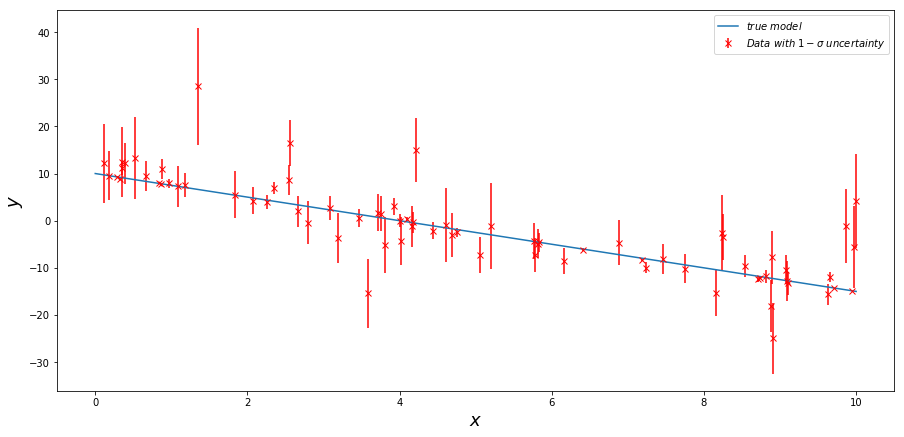

In [3]:
# 下面构造一组带噪声的模拟线性数据
rng = np.random.default_rng(5)
m = -2.5 # 模型的真实斜率
c = 10.0 # 模型的真实截距
N = 75 # 数据点个数
xi = 10*np.sort(rng.random(N)) # 在区间 (0,10) 上随机采样的位置
x = np.linspace(0,10,N)
y = c + m*x # 无噪声的真实模型
deltay = 0.5 + 5*np.abs(rng.normal(size=N)) # 各数据点的不确定度
Sigma = np.diag(deltay**2) # 协方差矩阵
W = np.diag(1.0/deltay**2) # 权重矩阵
epsilon = rng.multivariate_normal(np.zeros(N),Sigma) # 一次噪声实现
yi = c + m*xi + epsilon # 观测到的数据点

# 画出真实模型与带误差条的观测数据
plt.figure('Linear model', figsize=(15,7))
plt.plot(x,y,label=r'$true \ model$')
plt.errorbar(xi,yi,deltay,fmt='xr', label=r'$ Data \ with \ 1-\sigma \ uncertainty $')
plt.xlabel(r'$x$', fontsize=18)
plt.ylabel(r'$y$', fontsize=18)
plt.legend()


**图 2.10.2：** *线性模型示例数据。*

这通常就是你的数据大致会呈现的样子。注意，误差条较大的点可能会偏离真实模型相当远，因此回归时必须把这一点考虑进去。最自然的做法，是按观测方差的倒数对数据进行加权。为了展示不确定度（或者说逆权重）对结果的影响，下面我们会做两次回归：一次不考虑不确定度，一次考虑不确定度。

Best fit parameters without accounting for uncertainty c = 9.077610, m = -2.206786
Best fit parameters while accounting for uncertainty c = 10.034826, m = -2.490965


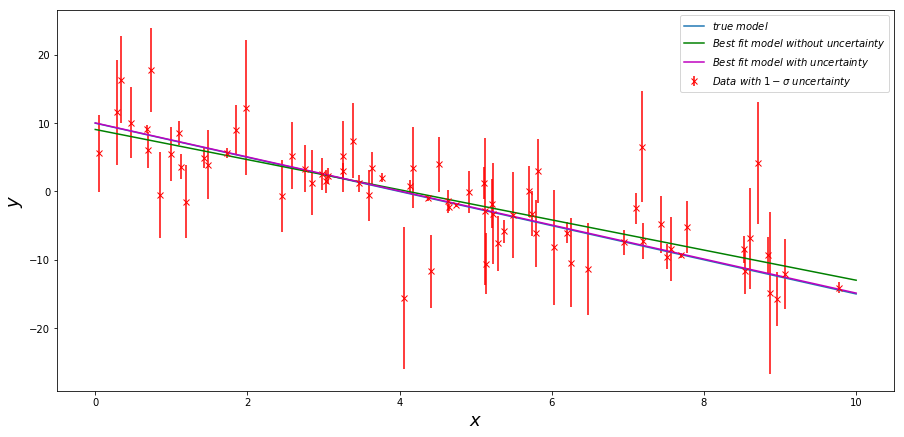

In [5]:
# 构造设计矩阵
A = np.ones([N,2])
A[:,1] = xi
AM = np.ones([N,2])
AM[:,1] = x 

# 不考虑不确定度时求解正规方程
xbar_no_uncertainty = solve_Normal(yi,A,np.eye(N))
print ("Best fit parameters without accounting for uncertainty c = %f, m = %f"%(xbar_no_uncertainty[0],xbar_no_uncertainty[1]))

# 重建对应的拟合函数
y_no_uncertainty = np.dot(AM,xbar_no_uncertainty)

# 考虑不确定度时求解正规方程
xbar = solve_Normal(yi,A,W)
print ("Best fit parameters while accounting for uncertainty c = %f, m = %f"%(xbar[0],xbar[1]))

# 重建对应的拟合函数
y_with_uncertainty = np.dot(AM,xbar)

# 画出两种拟合结果
plt.figure('Linear model', figsize=(15,7))
plt.plot(x,y,label=r'$true \ model$')
plt.errorbar(xi,yi,deltay,fmt='xr', label=r'$ Data \ with \ 1-\sigma \ uncertainty $')
plt.xlabel(r'$x$', fontsize=18)
plt.ylabel(r'$y$', fontsize=18)
plt.plot(x,y_no_uncertainty,'g',label=r'$Best \ fit \ model \ without \ uncertainty$')
plt.plot(x,y_with_uncertainty,'m',label=r'$Best \ fit \ model \ with \ uncertainty$')
plt.legend()


**图 2.10.3：** *考虑与不考虑不确定度时的线性回归示例。*

你应该会看到，加权回归给出的结果更准确。在干涉成像中，加权函数的作用并不只是在于处理不确定度；我们会在 $\S$ [5.4](../5_Imaging/5_4_imaging_weights.ipynb) 中看到其他例子。

这里的关键教训并不只针对直线拟合。凡是不同数据点可靠性不同、采样分布不均或噪声方差不同的场景，“权重”都会改变最优解的位置。干涉成像里自然加权、均匀加权和鲁棒加权之所以重要，背后的数学骨架与这里完全一致。

#### 2.10.3.3 卷积与 Toeplitz 矩阵 <a id='math:lin_alg:conv_toeplitz'></a>

下面我们换一个角度来看离散卷积算子。回忆一下，如果 ${\bf r} = ({\bf y} \circ {\bf z})$，那么有

$$ ({\bf y} \circ {\bf z})_k = r_k = \sum_{n\,=\,0}^{N-1} y_n z_{(k-n) \, mod \, N}. $$

这里我们将说明，如何把这一运算表示成“某种特殊矩阵（即 Toeplitz 矩阵）乘以一个向量”。理解 Toeplitz 矩阵最简单的方式，也许就是把它看成“每条对角线上的元素都相同”的矩阵。也就是说，如果 ${\bf T}$ 是 Toeplitz 矩阵，那么

$$ {\bf T} = \left[ \begin{array}{ccccc}
t_0 & t_1 & t_2 & \cdots & t_{n-1} \\
t_{-1} & t_0 & t_1 & \ & \ \\
t_{-2} & t_{-1} & t_0 & \ & \ \\
\vdots & \ & \ & \ddots & \ \\
t_{-(n-1)} & \ & \ & \cdots & t_0
\end{array} \right].  $$

换句话说，${\bf T} = [t_{i,j}; i,j=0,1,\cdots,n-1]$，其中 $t_{i,j} = t_{j-i}$，而 $t_{j-i}$ 上的下标对应的是 ${\bf T}$ 的第一行。这类矩阵在很多应用中都会出现，并且有很丰富的理论背景（例如可参见 [<cite data-cite='toeplitzreview'> Toeplitz and Circulant Matrices: A review </cite> &#10548;](http://ee.stanford.edu/~gray/toeplitz.pdf)）。这里我们不会深入这些理论，只关注其中一个更简单的子类，即循环矩阵（circulant matrix）。循环矩阵的每一行，都是上一行向右做循环移位后得到的。也就是说，如果 ${\bf C}$ 是一个循环矩阵，那么

$$ {\bf C} = \left[ \begin{array}{ccccc}
y_0 & y_1 & y_2 & \cdots & y_{n-1} \\
y_{n-1} & y_0 & y_1 & \ & \ \\
y_{n-2} & y_{n-1} & y_0 & \ & \ \\
\vdots & \ & \ & \ddots & \ \\
y_{1} & y_2 & \ & \cdots & y_0
\end{array} \right].  $$

等价地，也可以把 ${\bf C}$ 写成 ${\bf C} = [y_{i,j}; i,j=0,1,\cdots,n-1]$，其中矩阵元素只依赖于索引差（按模 $n$ 计算），即由第一行完全决定。现在考虑一个向量 $ {\bf z} = [z_0, z_1, \cdots, z_{n-1}]$ 与这种矩阵相乘的结果，即

$$ {\bf r} = {\bf C z}, \quad \Rightarrow \quad r_k = y_{n-k} z_0 + y_{n-(k-1)} z_1 + \cdots + y_0z_k + \cdots + y_{k-1} z_{n-1}, $$

其中右边用到了这样一个事实：${\bf r}$ 的第 $k$ 个分量，是 ${\bf C}$ 的第 $k$ 行与 ${\bf z}$ 做点积的结果。你应当能看出，这恰好就是上面给出的离散卷积定义。还要注意，循环矩阵在傅里叶基下可以被对角化。事实上，如果 ${\bf C}$ 是循环矩阵，${\bf F}$ 是离散傅里叶变换算子，那么

$$ {\bf C} = {\bf F} \psi {\bf F}^\dagger, \quad \mbox{其中} \quad {\bf C v} = \psi {\bf v}, $$

其中 $\psi$ 是特征值，${\bf v}$ 是特征向量。这里不再进一步展开细节；不过，所有循环矩阵的特征向量都与 $N${}^{th}$ 单位根有关，因此它们的特征值也可以直接求出。进一步地，正如我们后面会看到的，测量方程对应的 海森 矩阵就是一个循环矩阵，而它的卷积核正是仪器的点扩散函数。

从更高层的角度看，Toeplitz 与循环矩阵之所以重要，是因为它们对应“平移不变”的线性系统。只要系统对不同位置的响应只是平移而不改形，那么卷积结构就会自然出现；而一旦进入傅里叶基底，这类矩阵又会变得特别容易处理。成像中的脏波束、恢复波束以及许多快速卷积算法，实际上都在利用这一结构。

#### 代码演示：把一维干涉测量写成矩阵，并观察 $A^{H}A$

到这里为止，线性系统还停留在抽象写法 ${\bf b} = {\bf A x} + \epsilon$。对射电干涉测量而言，最重要的一步是把它真正翻译成“测量矩阵作用在天空向量上”。下面构造一个极简的一维成像例子：天空只由少数几个像素组成，观测量是若干条基线对应的复可见度，而矩阵 ${\bf A}$ 的每一行都对应一个采样到的空间频率。

这个演示想回答三个问题。第一，${\bf A}$ 到底长什么样；第二，为什么脏图像可以写成 ${\bf A}^{H}{\bf b}$；第三，为什么同样是傅里叶测量，不同的采样分布会让点扩散函数和问题病态性发生巨大变化。


In [ ]:
Npix = 16
pixel_index = np.arange(Npix) - Npix // 2
l = pixel_index / Npix
x_true = np.zeros(Npix)
x_true[[3, 8, 11]] = [1.0, 0.6, 0.35]


def measurement_matrix(u_coords, l_coords):
    return np.exp(-2j * np.pi * np.outer(u_coords, l_coords)) / np.sqrt(u_coords.size)


sampling_patterns = {
    'dense sampling': np.linspace(-18, 18, 48),
    'gappy sampling': np.r_[np.linspace(-4, 4, 12), np.linspace(10, 18, 4), np.linspace(-18, -10, 4)],
}

results = {}
for label, u_coords in sampling_patterns.items():
    A = measurement_matrix(u_coords, l)
    vis = A @ x_true
    H = A.conj().T @ A
    dirty = np.real(A.conj().T @ vis)
    psf = np.real(H[:, Npix // 2])
    svals = np.linalg.svd(A, compute_uv=False)
    sidelobe = np.max(np.abs(np.delete(psf, Npix // 2))) / psf[Npix // 2]
    print(f'{label:>15s}: condition number = {svals.max() / svals.min():8.2f}, peak sidelobe = {sidelobe:.3f}')
    results[label] = {
        'u': u_coords,
        'dirty': dirty,
        'psf': psf,
        'svals': svals,
    }

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].stem(pixel_index, x_true, linefmt='C0-', markerfmt='C0o', basefmt=' ')
axes[0, 0].set_xlabel('Image pixel')
axes[0, 0].set_ylabel('Brightness')
axes[0, 0].set_title('True 1D sky model')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].stem(pixel_index, results['dense sampling']['dirty'], linefmt='C1-', markerfmt='C1o', basefmt=' ')
axes[0, 1].set_xlabel('Image pixel')
axes[0, 1].set_ylabel('Dirty image value')
axes[0, 1].set_title(r'Dirty image: $A^H b$ (dense sampling)')
axes[0, 1].grid(alpha=0.3)

axes[0, 2].stem(pixel_index, results['gappy sampling']['dirty'], linefmt='C3-', markerfmt='C3o', basefmt=' ')
axes[0, 2].set_xlabel('Image pixel')
axes[0, 2].set_ylabel('Dirty image value')
axes[0, 2].set_title(r'Dirty image: $A^H b$ (gappy sampling)')
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(results['dense sampling']['u'], np.ones_like(results['dense sampling']['u']), '|', ms=14, label='dense sampling')
axes[1, 0].plot(results['gappy sampling']['u'], 0.83*np.ones_like(results['gappy sampling']['u']), '|', ms=14, label='gappy sampling')
axes[1, 0].set_ylim(0.7, 1.1)
axes[1, 0].set_xlabel(r'Sampled spatial frequency $u$')
axes[1, 0].set_yticks([])
axes[1, 0].set_title('Rows of the measurement matrix')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(fontsize=9, loc='lower left')

axes[1, 1].plot(pixel_index, results['dense sampling']['psf'], lw=2, label='dense sampling')
axes[1, 1].plot(pixel_index, results['gappy sampling']['psf'], lw=2, ls='--', label='gappy sampling')
axes[1, 1].set_xlabel('Pixel offset')
axes[1, 1].set_ylabel(r'Column of $A^H A$')
axes[1, 1].set_title(r'Dirty beam / normal matrix kernel')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(fontsize=9)

axes[1, 2].semilogy(results['dense sampling']['svals'] / results['dense sampling']['svals'].max(), 'o-', lw=2, label='dense sampling')
axes[1, 2].semilogy(results['gappy sampling']['svals'] / results['gappy sampling']['svals'].max(), 's--', lw=2, label='gappy sampling')
axes[1, 2].set_xlabel('Singular-value index')
axes[1, 2].set_ylabel('Normalized singular value')
axes[1, 2].set_title('Conditioning of the measurement operator')
axes[1, 2].grid(alpha=0.3)
axes[1, 2].legend(fontsize=9)

plt.tight_layout()
plt.show()


这个例子把若干后续章节里的“压缩写法”真正展开了。脏图像并不是某种神秘对象，它只是伴随算子 ${\bf A}^{H}$ 作用在数据向量上的结果；而 ${\bf A}^{H}{\bf A}$ 则是把真实天空模糊成脏图像的法方程核。若采样较均匀，点扩散函数旁瓣较低，奇异值也更平缓；若采样有明显缺口，旁瓣会上升，小奇异值会快速衰减，反演问题便更病态。

这正是后面成像章节反复出现的结构。`uv` 覆盖、脏波束、法方程、预条件和正则化，并不是彼此孤立的主题，而是同一个矩阵问题的不同切面。只要把 ${\bf A}$、${\bf A}^{H}$ 和 ${\bf A}^{H}{\bf A}$ 的角色分清，后面的公式就会容易得多。


***

* 下一节：[2.11 最小二乘与参数估计](2_11_least_squares.ipynb)
